# Práctica de Laboratorio: Métodos de Clustering en Machine Learning

**Equipo de laboratorio:** <código_del_equipo>  
**Nombre (miembro 1):** \<nombre1\> <apellido1_1> <apellido1_2>  
**Nombre (miembro 2):** \<nombre2\> <apellido2_1> <apellido2_2>

---

### Instrucciones Generales

* **Identificación:** Incluya su **nombre completo al inicio de todos los archivos** entregados.
* **Ejecución:** Entregue este notebook con **todas las celdas ejecutadas**. Asegúrese de que el código pueda ejecutarse de principio a fin sin errores (**Kernel -> Restart & Run All**). Los errores de ejecución pueden ser penalizados.
* **Modularización:** Las funciones deben definirse en un **archivo separado (.py)**, no en el notebook. Incluya todos los archivos necesarios para la ejecución en su entrega.
* **Calidad del Informe:** El reporte será evaluado por su **exactitud**, pero también por su **claridad, concisión e integridad**.
* **Visualización:** Utilice **figuras y tablas** para resumir los resultados e ilustrar las discusiones.
* **Fuentes y Citas:** Puede usar materiales del curso o fuentes externas. Si usa material externo, las **fuentes deben ser citadas** en formato APA ([Guía APA 7](https://pitt.libguides.com/citationhelp/apa7)). La falta de referencias o un formato deficiente será penalizado.
* **IA Generativa:** Se permite el uso de herramientas de IA para consulta (especificando cuál), pero **está estrictamente prohibido usar IA para generar código**.

---

### Formato de Entrega

La entrega debe ser un único archivo `.zip` nombrado como:  
`AA3_2025_2026_P01_<equipo_lab>_<apellido1_1>_<apellido2_1>.zip`  
*(Ejemplo: `AA3_2025_2026_P01_V03_munyoz_deLaRosa.zip`)*

**El archivo comprimido debe contener:**
1.  **Este notebook de Python** con las soluciones (código, figuras, tablas y explicaciones). Las derivaciones manuscritas pueden incluirse como imágenes.
2.  **Archivos `.py` y adicionales** necesarios para que el notebook se ejecute secuencialmente.
3.  **Archivo PDF** generado desde el notebook (Exportar a HTML -> Imprimir como PDF).



# Modelos de Clustering: Taxonomía y Comportamiento

En esta sección se presenta una taxonomía de los algoritmos de aprendizaje no supervisado. El objetivo es identificar el modelo óptimo según la morfología de los datos, la presencia de ruido y los requisitos de interpretabilidad.

Estudiaremos los siguientes métodos y sus escenarios de aplicación:

* **Jerárquico:** Análisis de conectividad y estructuras anidadas mediante dendrogramas.
* **K-means:** Optimización de centroides y selección del número óptimo de clústeres $k$.
* **Fuzzy C-Means :** Implementación de clustering donde cada punto tiene un grado de pertenencia a varios grupos.
* **GMM (Gaussian Mixture Models):** Modelado probabilístico basado en distribuciones gaussianas para capturar formas elípticas.
* **DBSCAN / HDBSCAN:** Modelos basados en densidad. Analizaremos su robustez frente al **ruido** y el impacto de la **alta dimensionalidad**.
* **Spectral Clustering:** Uso de autovalores de matrices de afinidad para identificar clústeres no convexos y complejos.
* **Deep clustering:** Cálculo de espacios latentes para clustering.

## 1. Clustering Jerárquico

El clustering jerárquico construye una jerarquía de clústeres representable mediante un **dendrograma**. No requiere definir el número de clústeres $k$ a priori, permitiendo visualizar la estructura de los datos en diferentes niveles de disimilitud.

Existen dos enfoques principales:
* **Aglomerativo (Bottom-up):** Cada punto comienza como su propio clúster y se van fusionando los más cercanos.
* **Divisivo (Top-down):** Todos los puntos comienzan en un único clúster que se va dividiendo sucesivamente.

Aquí puedes encontrar funciones útiles para su implementación y visualización: 
https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html



### Referencias Académicas
Para profundizar en la teoría de los métodos de enlace (*linkage*) y métricas de distancia, se recomiendan las siguientes fuentes:

1.  **Murtagh, F., & Contreras, P. (2012).** *Algorithms for hierarchical clustering: An overview.* Wiley Interdisciplinary Reviews: Data Mining and Knowledge Discovery, 2(1), 86-97.
2.  **James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013).** *An Introduction to Statistical Learning*. Springer. (Capítulo 10.3: Hierarchical Clustering).



### Ejercicio 1: Taxonomía Automática mediante Clustering Jerárquico

#### Contexto
En este ejercicio, utilizaremos el **Zoo Data Set** (disponible en el repositorio **UCI Machine Learning**, ID: 111). Este conjunto de datos contiene 101 animales definidos por 16 atributos morfológicos. El objetivo es evaluar si un algoritmo no supervisado puede agrupar especies de forma coherente con la taxonomía biológica real sin conocer las etiquetas de clase previamente.

#### Tareas a realizar
1.  **Carga de datos:** Acceda al dataset utilizando la librería `ucimlrepo`.
2.  **Preprocesamiento:** ¿Es necesario escalar o normalizar los datos? En caso afirmativo hágalo.
3.  **Modelado:** Utilize la función que estime pertinente de `cluster.hierarchy`.
4.  **Visualización:** Genere un **dendrograma** que incluya los nombres de los animales en el eje de las abscisas.


Tenga cuidado con la elección del método y razone si el seleccionado es correcto.



Datasets columns are: Index(['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator',
       'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail',
       'domestic', 'catsize'],
      dtype='object')


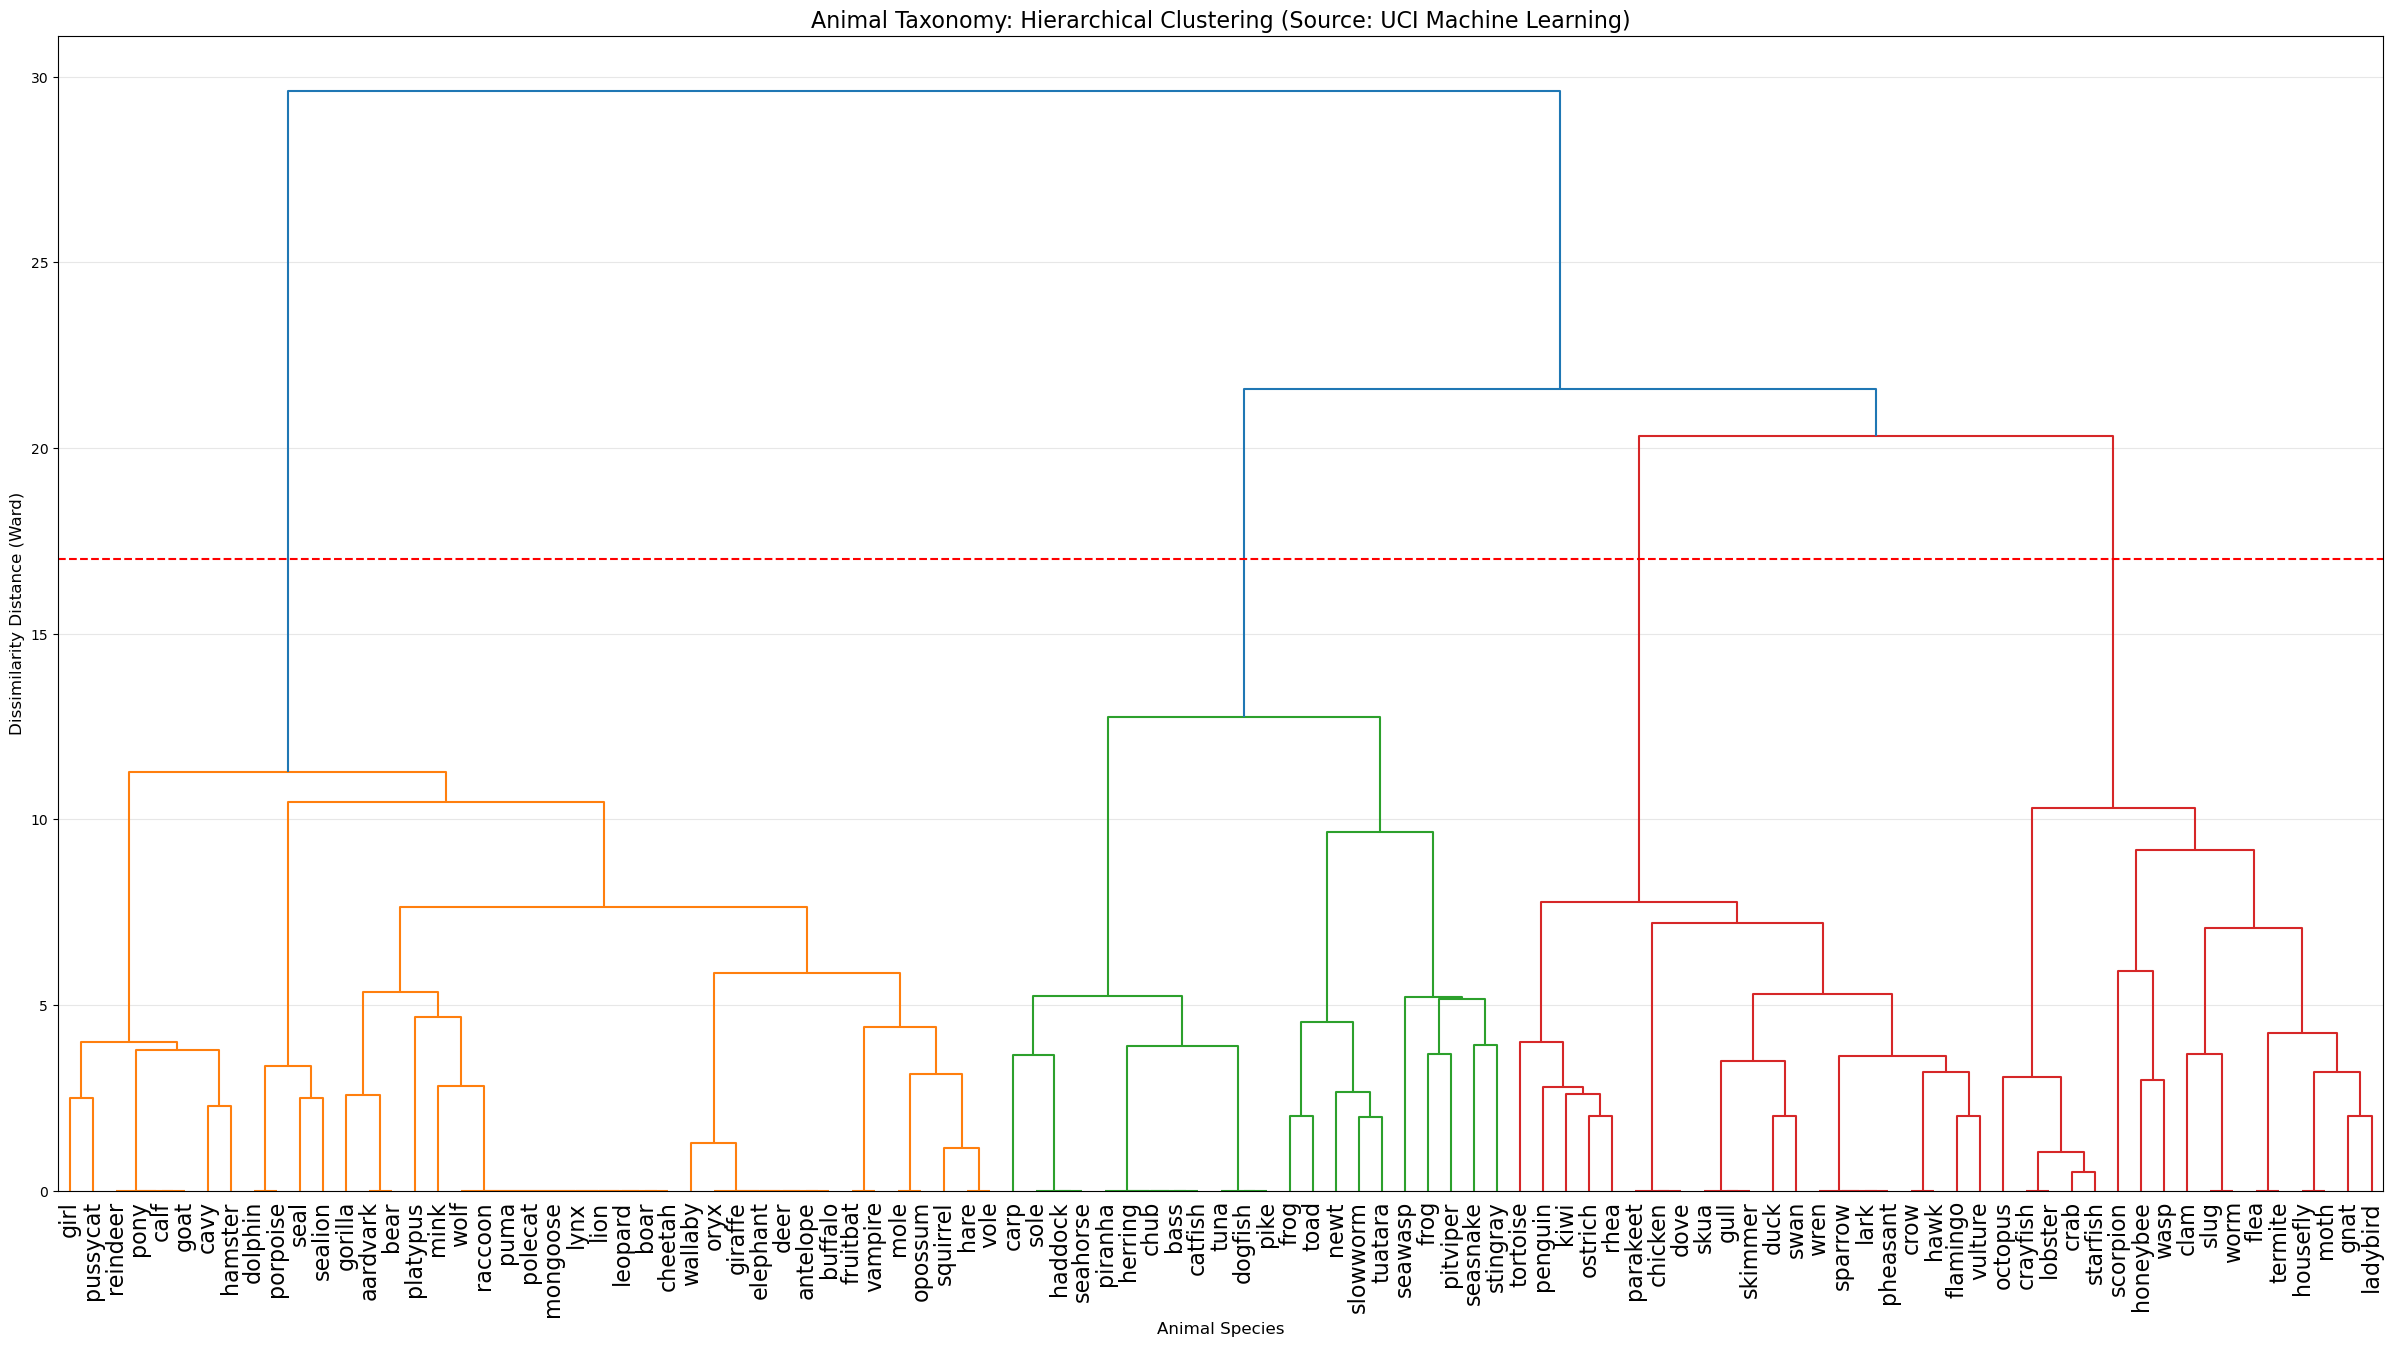

In [1]:
from models.hierarchical import train_hierarchical, plot_hierarchical
from ucimlrepo import fetch_ucirepo

dataset_id = 111
zoo = fetch_ucirepo(id=dataset_id)
X = zoo.data.features
zoo_names = zoo.data.original['animal_name'].values.tolist()
print(f'Datasets columns are: {X.columns}')
Z = train_hierarchical(X)
plot_hierarchical(zoo_names, Z)

### Cuestiones de Evaluación: Clustering Jerárquico

**1. Interpretación del Dendrograma y Distancia:**
Observando el eje vertical ($y$) del dendrograma generado: ¿Qué representa específicamente esa altura en el momento en que dos ramas se fusionan? Si decidieras realizar un "corte" horizontal para obtener exactamente 4 grupos, ¿en qué rango de valores de distancia deberías situar dicho corte?

El eje vertical representa el grado de disimilitud entre un par de clústers. El método de Ward define la disimilitud como una medida proporcional a la distancia euclídea en la primera iteración -asignando un cluster para cada patrón-. En las siguientes iteraciones del algoritmo, la disimilitud de cara a fusionar clusters (para hacer más general el agrupamiento; el propósito de la clusterización) se pondera positivamente la disimilitud entre los clústers a fusionar y negativamente la que hay entre clusters ajenos. Esto, intuitivamente, es una forma de minimizar la varianza inter-clúster al fusionar, escogiendo aquella fusión de clusters (en cada iteración) que minimice la disimilitud entre los conjuntos hipotéticamente fusionados y el resto de conjuntos. Esto se resume en la expresión de la disimilitud de Ward:

$$ \text{Disimilitud} = d(u, v) = d(\{s U t\}, v) = \sqrt{
\frac{|v| + |s|}{T} \, d(v,s)^2
+
\frac{|v| + |t|}{T} \, d(v,t)^2
-
\frac{|v|}{T} \, d(s,t)^2
} $$

Fuente: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html. Fecha de acceso: 2 de marzo de 2026. 

**2. Investigación de Métodos de Enlace (Linkage):**
Consulta la documentación de `scipy.cluster.hierarchy.linkage` y compara los métodos **'ward'**, **'single'** (salto mínimo) y **'complete'** (salto máximo):
* Explica brevemente la diferencia lógica entre ellos.

- Single: su disimilitud es igual a la distancia euclídea (por defecto, pueden considerarse otras) mínima entre dos clústers (la distancia entre sus dos puntos más cercanos). 

- Complete: su disimilitud es igual a la distancia euclídea (por defecto) máxima entre dos clústers. Es decir, la distancia entre sus dos puntos más aleados. 

- Ward: como se explicó antes, su disimilitud es una medida de varianza al fusionar. 

La tarea es minimzar esa disimilitud para esos tres métodos. 

* ¿Cuál de estos métodos tiende a producir el efecto de "encadenamiento" (*chaining*) y cuál suele generar clústeres más compactos y equilibrados?

El encadenamiento se produce en mayor medida por el método single. Esto se debe a que su criterio beneficia a los clusters más cercanos, pudiendo ocurrir en algún caso extremo, que el clúster sea una cadena alargada. El complete, por su parte, también es sensible a la forma del clúster. En general, ambos dos pueden dar lugar a fusiones con poco sentido e inestables. Mientras que el de Ward siempre dará lugar a fusiones que tienen en cuenta la homogeneidad interna de los grupos. 

**3. El Impacto del Escalado:**
El dataset Zoo tiene variables binarias (0/1), pero la variable `legs` (número de patas) tiene un rango de 0 a 8 ¿Tiene esto alguna relevancia?

Absolutamente, pero no tiene por qué ser negativo. Es claro que tener un número alto de patas de posiciona a una distancia considerable de los animales con 2 o 4 patas. Sin embargo, habría que evaluar dentro del contexto si esta penalización está sesgando al modelo a la hora de seleccionar clústers o si, por el contrario, le ayuda a tomar decisiones más acertadas. 

**4. Reflexión sobre la Taxonomía:**
Localiza en el gráfico a los animales **'dolphin'** (delfín) y **'platypus'** (ornitorrinco). 
* ¿Están agrupados con el resto de los mamíferos o han quedado aislados en ramas diferentes? 

Interpretando que los mamíferos son el cluster de color naranja  (todo parece indicarlo), sí, están agrupados correctamente. Están situados bastante cerca el uno del otro.  

* Justifica, basándote en los atributos del dataset (como `eggs`, `milk` o `aquatic`), por qué el algoritmo los ha situado en esa posición específica de la jerarquía.

Uno de los pocos rasgos que los diferencia es que el ornitorrinco pone huevos y el delfín no. Al fin y al cabo, esto los sitúa relativamente cerca los unos de otros, pues comparten bastantes aspectos en común (son mamíferos)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

## K-means, Hiperparametrización y Sensibilidad Geométrica

### Contexto
El algoritmo **K-means** es un método de clustering basado en centroides que busca minimizar la varianza intra-cluster (inercia). A diferencia de los métodos jerárquicos, K-means es extremadamente escalable, pero introduce dos desafíos técnicos: la necesidad de predefinir el número de clústeres ($k$) y la asunción de que los grupos tienen una geometría esférica y convexa.

### Objetivos de la actividad
1.  **Optimización de Hiperparámetros:** Determinar el valor de $k$ de forma objetiva utilizando métricas de validación interna.
2.  **Análisis de Robustez:** Evaluar el desempeño del algoritmo ante diferentes morfologías de datos.

### Tareas a realizar


#### A. Selección del $k$ óptimo
Para el **Dataset 1**, implemente una búsqueda del hiperparámetro $k$ (en un rango de 2 a 10) utilizando:
1.  **El Método del Codo (Elbow Method):** Grafique la evolución de la **Inercia** y detecte el punto de inflexión. (Vea atributo `inertia_`de `sklearn.cluster.KMeans`).
2.  **Análisis de Silueta:** Calcule y grafique el **Silhouette Score**. Explique qué indica un valor cercano a 1 frente a uno cercano a 0. (Vea `sklearn.metrics.silhouette_score`).



#### B. Visualización de Resultados
Ejecute el algoritmo en ambos datasets y genere una comparativa visual:
* Muestre los clústeres asignados mediante colores.
* Represente la posición final de los **centroides** con un marcador distintivo (ej. una 'X' roja).
* **Relevancia:** Documente por qué en el dataset de lunas el algoritmo divide los datos de forma lineal a pesar de la estructura evidente.



### Cuestiones de Evaluación: K-means

1. **Geometría y Centroides:** Analizando el gráfico del escenario de las "lunas", ¿por qué K-means es incapaz de seguir la forma natural de los datos? Relacione su respuesta con el concepto de **fronteras de decisión de Voronoi**.
2. **Interpretación de Métricas:** Si el Método del Codo muestra un descenso constante sin un "codo" claro, ¿qué información nos aporta el Coeficiente de Silueta para tomar una decisión?
3. **Maldición de la Dimensionalidad:** Investigue y explique brevemente cómo afecta el aumento de dimensiones (variables) al cálculo de la distancia euclídea en K-means.
4. **¿Se podría utilizar `gridSearch` para buscar el mejor número de agrupaciones? Razone la respuesta.


Data shape: (500, 2)


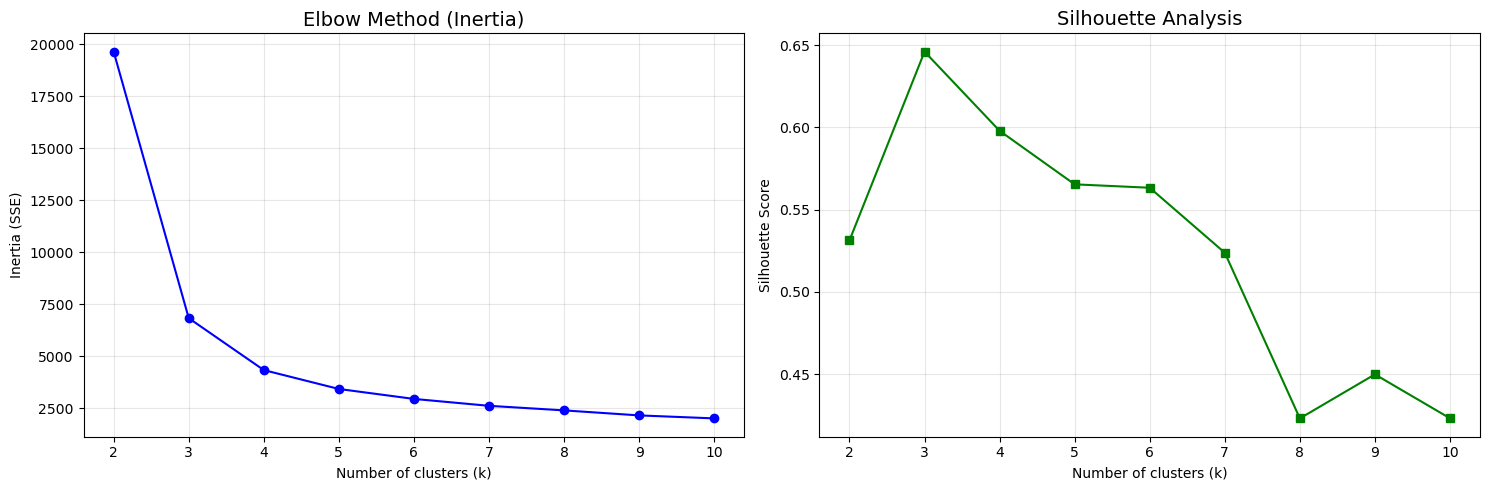

In [2]:
from utils.generate_data import generate_gaussian_blobs
from models.kmeans import evaluate_kmeans_hyperparameters
from visualization.visualize_optimization_curves import visualize_optimization_curves
import warnings

# warnings.filterwarnings("ignore", category=UserWarning)

# Generate synthetic spherical data
X_blobs, y_real_1 = generate_gaussian_blobs()

print(f'Data shape: {X_blobs.shape}')
max_k = 10 
k_list_1 = list(range(2, max_k + 1))  
inercias_1, siluetas_1 = evaluate_kmeans_hyperparameters(X_blobs, k_list_1)
visualize_optimization_curves(k_list_1, inercias_1, siluetas_1)

A la vista de esto, elegiríamos $k= 3$ por observaciones en ambos gráficos:

- En el método del codo que la inercia empieza a converger a a 2500 a partir de $k= 3$ lo que nos indica el valor óptimo que reduce complejidad en el modelo pero minimiza inercia. 

- Podemos confirmar la hipótesis de 3 como valor óptimo ya que el método Silhouette nos indica que para $k= 3$ la separación entre clústers es la máxima lo cual muestra claridad en el modelo. El método de Silhouette pondera, para cada punto, la distancia promedio entre puntos de mismo cluster y la distancia promedio entre clústers. Y posteriormente, pondera esas métricas para cada $k$ planteado, resultado mejor aquel $k$ que maximice las distanicas. En particular, ek $k$ que maximiza:

$$ s(i) = \frac{(b(i) - a(i))}{max(a(i), b(i))}$$

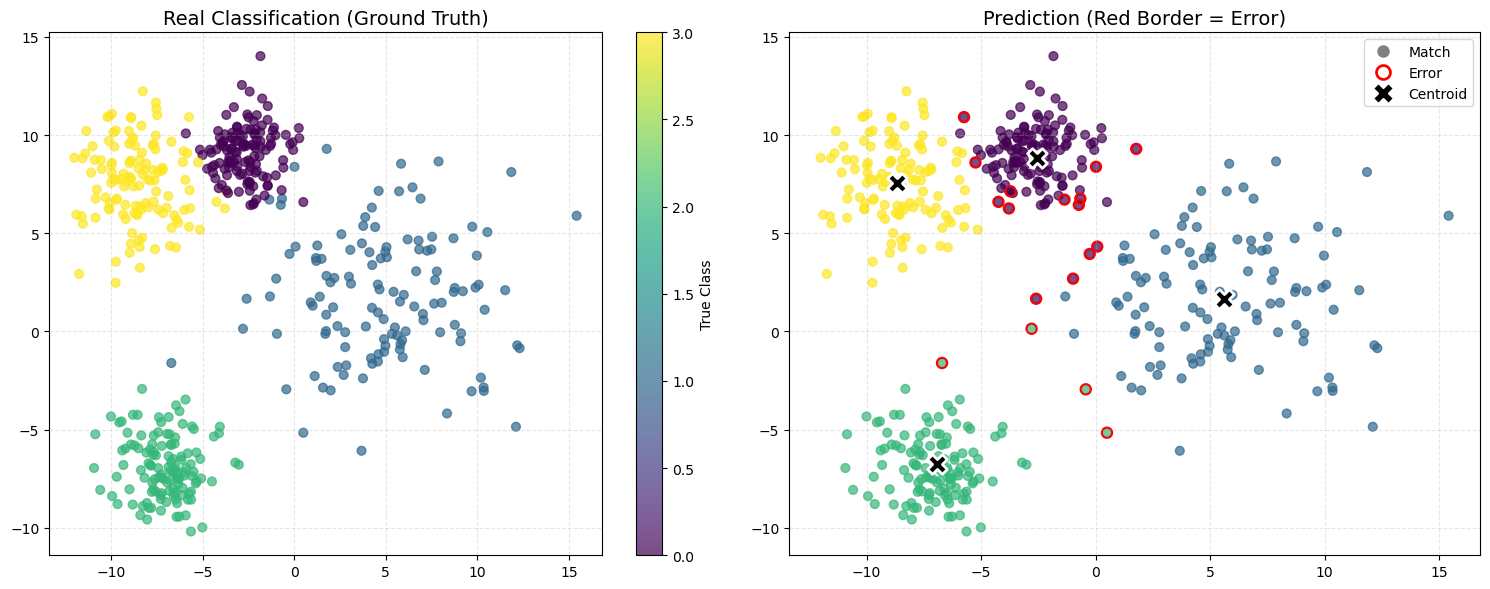

In [3]:
from models.kmeans import train_kmeans
from visualization.visualize_clustering_comparison import visualize_clustering_comparison

k = 4
y_preds_1, centroids_1 = train_kmeans(X_blobs, n_clusters=k)
visualize_clustering_comparison(X=X_blobs, y_true=y_real_1, y_pred=y_preds_1, centroids=centroids_1)

Moon dataset shape: (500, 2)


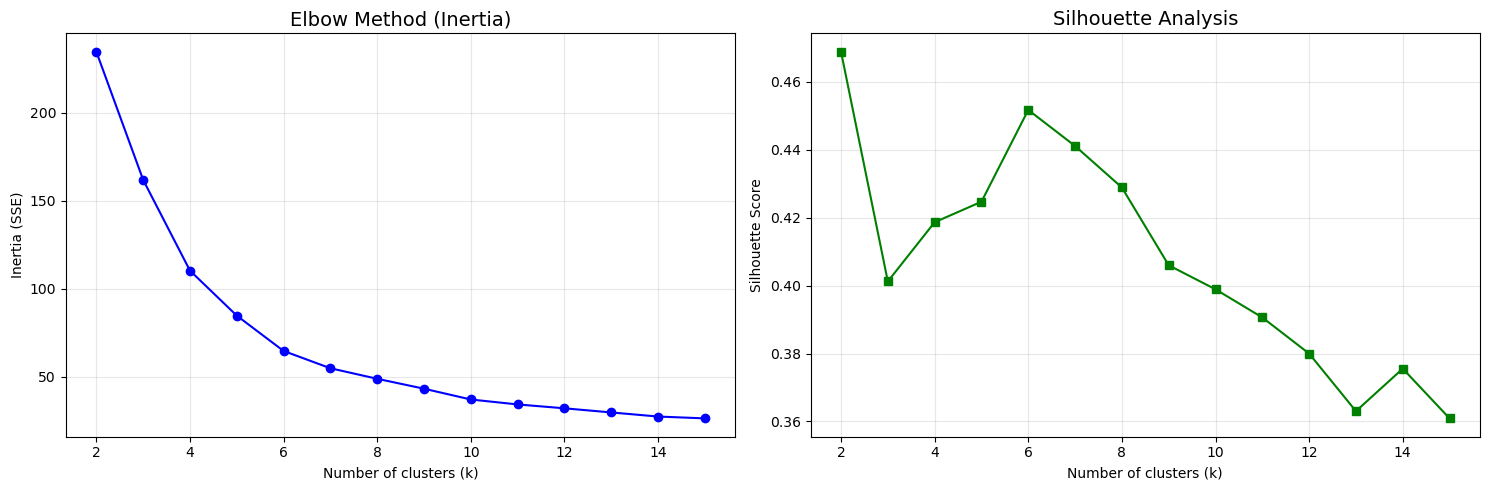

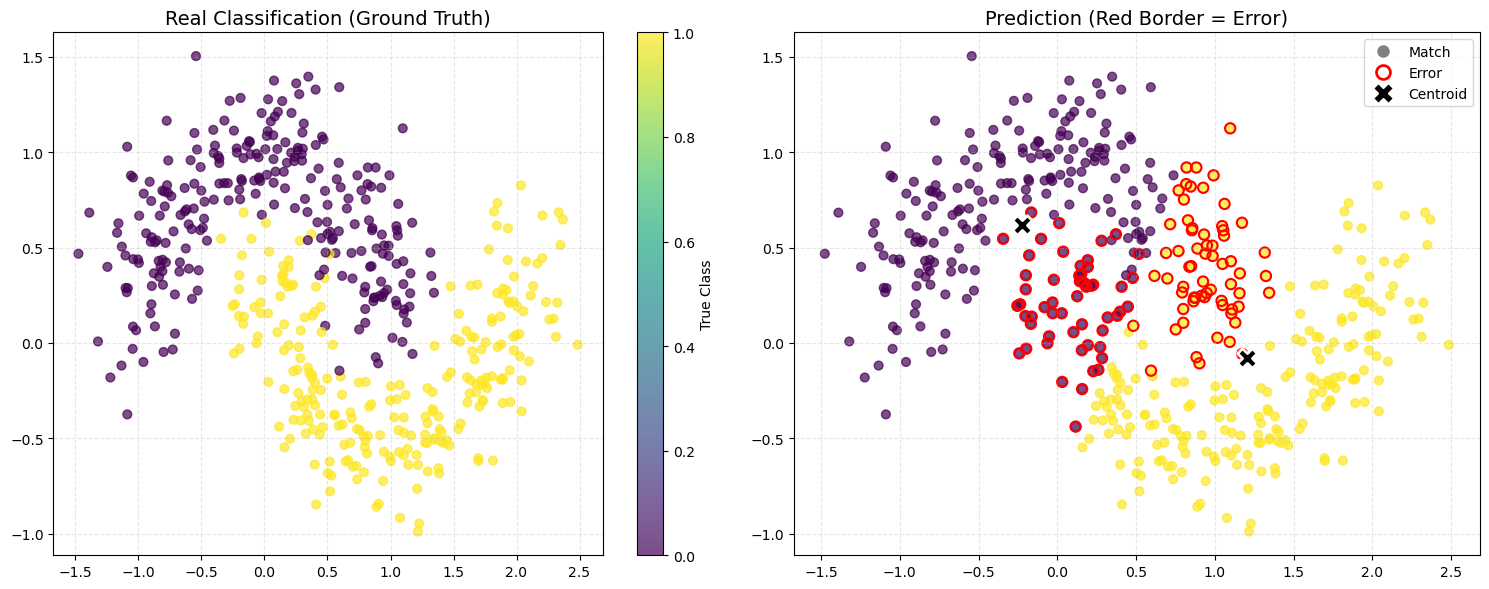

In [4]:
from utils.generate_data import generate_moons_data

# Generate moon-shaped data
X_moons, y_real_moons = generate_moons_data()

print(f"Moon dataset shape: {X_moons.shape}")

max_k_moons = 15
k_list_moons = list(range(2, max_k_moons + 1))

# Hyperparameter search for KMeans
inertias_moons, silhouettes_moons = evaluate_kmeans_hyperparameters(X_moons, k_list_moons)
visualize_optimization_curves(k_list_moons, inertias_moons, silhouettes_moons)

# Train and visualize KMeans on moons
k_moons = 2
y_pred_moons, centroids_moons = train_kmeans(X_moons, n_clusters=k_moons)
visualize_clustering_comparison(
    X=X_moons,
    y_true=y_real_moons,
    y_pred=y_pred_moons,
    centroids=centroids_moons
)

# 3. Fuzzy Clustering (Clustering Difuso)

A diferencia de los métodos de*hard clustering* como K-means, donde cada dato pertenece exclusivamente a un único grupo, el **Fuzzy Clustering** (o *soft clustering*) permite que los datos tengan grados de pertenencia a múltiples clústeres simultáneamente.

### Fundamentos Teóricos
Según se describe en la **Wikipedia**, el algoritmo más extendido dentro de esta familia es el **Fuzzy C-means (FCM)**. Este método es particularmente valioso cuando las fronteras entre los grupos no están claramente definidas o cuando existen puntos de datos que podrían clasificarse razonablemente en más de una categoría.



### Formulación Matemática
El objetivo del algoritmo es minimizar la siguiente función de coste:

$$J_m = \sum_{i=1}^n \sum_{j=1}^c w_{ij}^m \|x_i - c_j\|^2$$

Donde:
* $n$ es el número de puntos de datos.
* $c$ es el número de clústeres.
* $w_{ij}$ es el **grado de pertenencia** del punto $x_i$ al clúster $c_j$.
* $m$ es el **fuzzifier** (parámetro de difusividad), un número real $m \geq 1$.

**Restricción fundamental:** Para cualquier punto de datos $x_i$, la suma de sus coeficientes de pertenencia a todos los clústeres debe ser igual a 1:
$$\sum_{j=1}^c w_{ij} = 1$$

### Relevancia del Parámetro $m$
El hiperparámetro $m$ define la naturaleza del algoritmo:
* Si $m \to 1$, el algoritmo tiende a comportarse como un clustering rígido (similar a K-means).
* A medida que $m$ aumenta, la incertidumbre crece y las fronteras entre los clústeres se vuelven más "borrosas", permitiendo que los puntos en las zonas de transición tengan pesos repartidos entre varios grupos.

---

### Ejercicio: Implementación de FCM
Para este apartado, deberá desarrollar en su archivo `.py` una función que implemente el ciclo iterativo de actualización de la matriz de pertenencia $W$ y los centroides $C$. 

**Pregunta de reflexión:** Tras ejecutar el algoritmo en los conjuntos de datos sintéticos, identifique un punto situado en la intersección de dos grupos. ¿Qué valores presenta su vector de pertenencia $w_i$? Explique cómo esta información ayuda a entender la estructura del dataset mejor que una etiqueta única.


### Referencia Bibliográfica

> Wikipedia contributors. (Febrero 2026). *Fuzzy clustering*. Wikipedia, The Free Encyclopedia. Retrieved from https://en.wikipedia.org/wiki/Fuzzy_clustering

In [5]:
from models.fuzzy_c_means import train_fuzzy_c_means
# Get datasets for the success scenario
for n_clusters, data_generator in [(4, generate_gaussian_blobs), (2, generate_moons_data)]:
    X, y_true = data_generator()
    print(f"Generating data with {data_generator.__name__} and {n_clusters} clusters")

    y_pred_fuzzy, centroids_fuzzy = train_fuzzy_c_means(X, n_clusters=n_clusters)

    # Visualize results
    visualize_clustering_comparison(
        X=X,
        y_true=y_true,
        y_pred=y_pred_fuzzy,
        centroids=centroids_fuzzy
    )


Generating data with generate_gaussian_blobs and 4 clusters


/Users/ivandominguez/Desktop/practicas3segundocuatri/apaut3/AA3_2025_2026_P01_12_Miranda_Dominguez/models/fuzzy_c_means.py:60: RuntimeWarning: Maximum number of iterations reached.
  warnings.warn("Maximum number of iterations reached.", RuntimeWarning)


NameError: name 'U' is not defined

# 4. Modelos de Mezclas Gaussianas (GMM) y Algoritmo EM

Mientras que K-means asume que los clústeres son esféricos (solo considera la media), los **Gaussian Mixture Models (GMM)** asumen que los datos son generados por una mezcla de varias distribuciones gaussianas. Esto permite que el modelo se adapte a clústeres con formas elípticas, variando no solo en su centro, sino también en su ancho y orientación.

### Fundamento Teórico: El Algoritmo EM
GMM es un modelo probabilístico que se optimiza mediante el algoritmo **Expectation-Maximization (EM)**. A diferencia de la asignación rígida de K-means, EM itera dos pasos hasta converger:

1.  **Paso E (Expectation):** Se calcula la probabilidad (responsabilidad) de que cada punto pertenezca a cada clúster, basándose en los parámetros actuales.
2.  **Paso M (Maximization):** Se recalculan los parámetros de las gaussianas (media $\mu$, covarianza $\Sigma$ y peso $\pi$) para maximizar la verosimilitud de los datos dadas las probabilidades calculadas en el paso anterior.

La probabilidad de un punto $x$ en una mezcla de $K$ componentes es:
$$p(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)$$

Donde $\Sigma_k$ es la **matriz de covarianza**, que determina la forma geométrica del elipsoide.



### Tipos de Covarianza
Un hiperparámetro clave en `sklearn` es `covariance_type`, que restringe la libertad de la forma del clúster:
* `'spherical'`: Restringe a formas esféricas (similar a K-means).
* `'diag'`: Elipses alineadas con los ejes (sin correlación entre variables).
* `'full'`: Elipses con cualquier orientación y forma (modela correlaciones).

---

### Referencias Bibliográficas
> Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. (Capítulo 9: Mixture Models and EM).

---

### Ejercicio 4: Flexibilidad Geométrica y Probabilidad
En este ejercicio, generaremos datos **anisotrópicos** (estirados) para demostrar la superioridad de GMM frente a K-means en estructuras no circulares.

**Tareas:**
1. Muestre la comparativa visual pedida para GMM y los datos `generar_datos_gaussianos`, `generar_datos_circulos`. 
2. Responda razonadamente: ¿Cree que para el problema de las lunas GMM lo haría mejor que los métodos anteriores? ¿por qué?
3. Compara el problem `datos gaussianos` con K-means y Fuzzy-C means. ¿qué crees que está pasando?

Running GMM on Gaussian dataset with 4 components


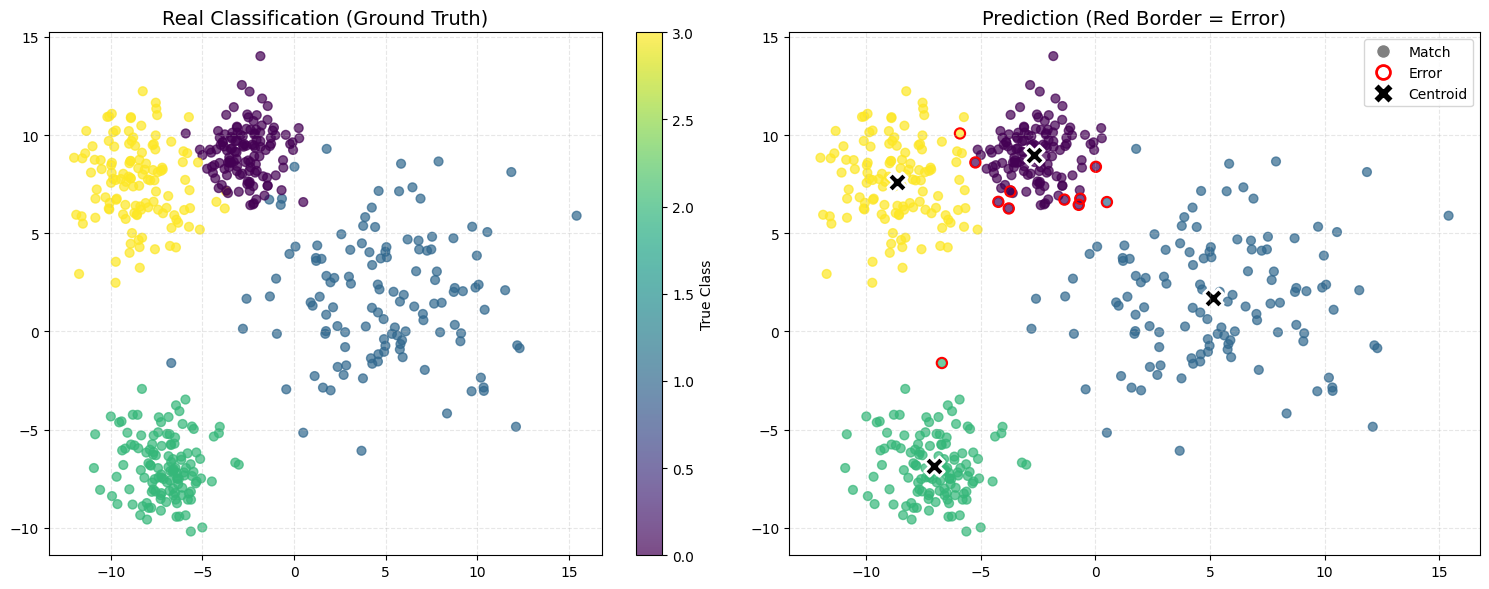

Running GMM on Concentric circles dataset with 2 components


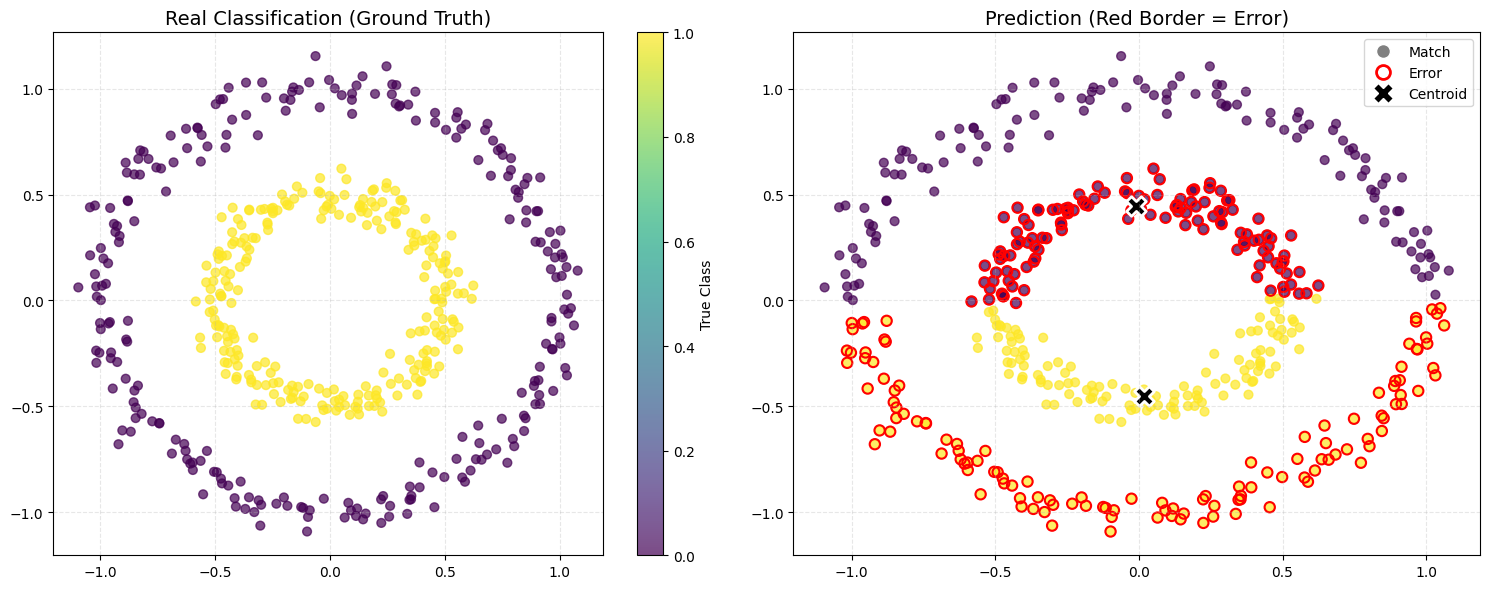

In [ ]:
from models.gmm import train_gmm
from utils.generate_data import generate_circles_data
experiments = [
    ("Gaussian dataset", 4, generate_gaussian_blobs),
    ("Concentric circles dataset", 2, generate_circles_data),
]

for dataset_name, n_components, data_generator in experiments:
    X, y_true = data_generator()
    print(f"Running GMM on {dataset_name} with {n_components} components")
    y_pred, gmm_centroids = train_gmm(X, n_components=n_components)
    visualize_clustering_comparison(X, y_true, y_pred, gmm_centroids)

# 5. Clustering Basado en Densidad: DBSCAN y HDBSCAN

Hasta ahora, hemos utilizado algoritmos que asumen que los clústeres tienen una forma geométrica definida (esférica o elíptica) y que todos los puntos pertenecen a algún grupo. Sin embargo, los datos reales suelen tener formas irregulares y contener ruido (puntos que no pertenecen a ningún clúster).

Para resolver esto, utilizamos algoritmos basados en **densidad**: un clúster es una región del espacio donde los puntos están muy juntos, separada de otras regiones por zonas de baja densidad.



### 5.1 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN no requiere especificar el número de clústeres ($k$). En su lugar, utiliza dos parámetros para definir la densidad:
* **$\epsilon$ (epsilon):** El radio de vecindad alrededor de un punto.
* **MinPts (`min_samples`):** El número mínimo de puntos necesarios dentro de ese radio $\epsilon$ para considerar que se ha formado una zona densa.

**Clasificación de Puntos:**
1.  **Núcleo (Core):** Tiene al menos *MinPts* vecinos en su radio $\epsilon$.
2.  **Borde (Border):** No tiene suficientes vecinos para ser núcleo, pero está dentro del radio de un punto núcleo.
3.  **Ruido (Noise):** No es núcleo ni borde. El algoritmo lo etiqueta como **-1**.

### 5.2 HDBSCAN (Hierarchical DBSCAN)
DBSCAN tiene una gran debilidad: **falla si los clústeres tienen densidades muy diferentes** (uno muy denso y otro muy disperso), ya que requiere un único $\epsilon$ global.

**HDBSCAN** soluciona esto transformando DBSCAN en un algoritmo jerárquico:
1.  Construye un árbol de clústeres variando $\epsilon$ dinámicamente.
2.  Utiliza la **estabilidad** del clúster para "cortar" el árbol en el punto óptimo.
3.  Solo requiere un parámetro principal: `min_cluster_size` (tamaño mínimo del grupo).



---

### Referencias Bibliográficas
> Ester, M., Kriegel, H. P., Sander, J., & Xu, X. (1996). A density-based algorithm for discovering clusters in large spatial databases with noise. *KDD-96 Proceedings*, 226-231.

> McInnes, L., Healy, J., & Astels, S. (2017). hdbscan: Hierarchical density based clustering. *Journal of Open Source Software*, 2(11), 205.

---

### Ejercicio 5: El Desafío de los Círculos Concéntricos

En este ejercicio, demostraremos por qué la geometría importa.
1.  **Datos:** Utilice los datos de círculos.
2.  **Comparativa:** Entrene K-means y DBSCAN sobre estos datos.
3.  **Visualización:** Utilice `visualizar_comparativa_clustering`.
    * Observe cómo K-means parte los anillos por la mitad (error geométrico).
    * Observe cómo DBSCAN sigue la curvatura perfecta de los anillos.
4. ¿Cómo ha elegido el valor de eps para DBSCAN? ¿Qué pasaría si los datos fueran ruidosos? Pruebe el problema de las lunas y comente qué está ocurriendo.
5. Mide la calidad con:
 *. Within-Cluster Sum of Squares (WCSS / Inercia):** Mide la compacidad. Es la suma de las distancias al cuadrado de cada punto a su centroide. K-means intenta minimizar esto.
    $$WCSS = \sum_{j=1}^{k} \sum_{x_i \in C_j} \| x_i - \mu_j \|^2$$
    *(Nota: Solo es útil para comparar diferentes `k` en K-means mediante el método del codo, no para comparar algoritmos distintos).*

* **Coeficiente de Silueta (Silhouette Score):**
    Evalúa si un punto está en el clúster correcto comparando su distancia a los puntos de su propio grupo (cohesión) frente a los puntos del grupo vecino más cercano (separación).
    * Rango: **[-1, 1]**. 
    * Valores cercanos a **1** indican clústeres densos y bien separados. Valores negativos indican puntos mal clasificados.



Generating data with: generate_circles_data
Running DBSCAN...


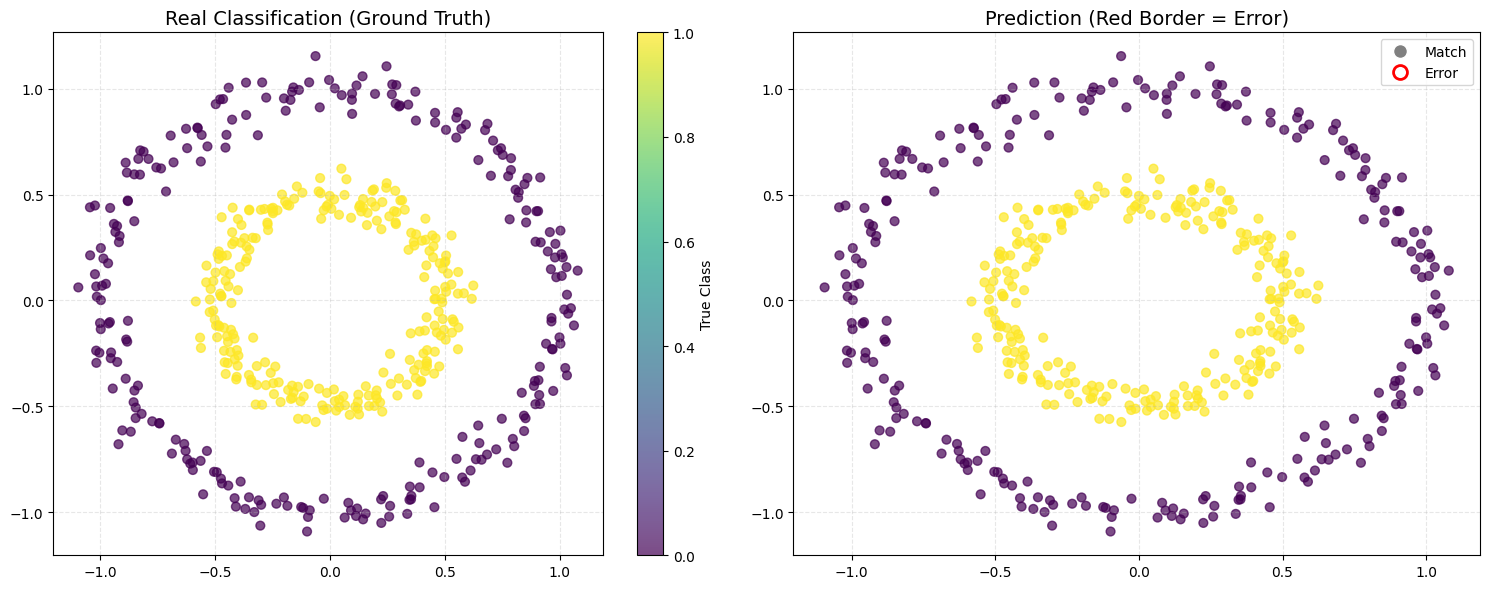

Running HDBSCAN...


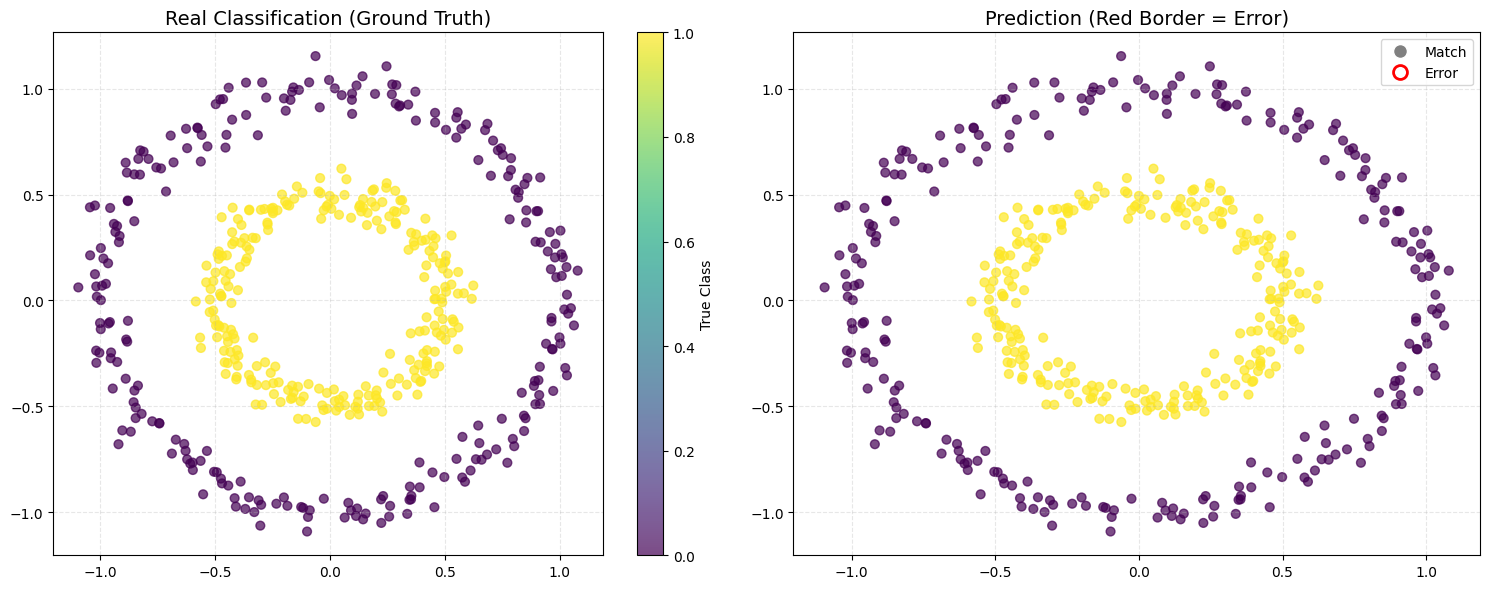

In [ ]:
from models.density_methods import train_dbscan, train_hdbscan
from utils.generate_data import generate_circles_data
from visualization.visualize_clustering_comparison import visualize_clustering_comparison

# Neighborhood radius for DBSCAN
eps_value = 0.2

# Iterating through the generators (starting with concentric circles)
for data_generator in [generate_circles_data]:
    X, y_true = data_generator()
    print(f"Generating data with: {data_generator.__name__}")

    # 1. DBSCAN Execution
    # Note: Success here depends heavily on the 'eps' value
    print("Running DBSCAN...")
    y_dbscan = train_dbscan(X, eps=eps_value)
    visualize_clustering_comparison(X=X, y_true=y_true, y_pred=y_dbscan)

    # 2. HDBSCAN Execution
    # Note: More robust as it doesn't require a fixed 'eps'
    print("Running HDBSCAN...")
    y_hdbscan = train_hdbscan(X)
    visualize_clustering_comparison(X=X, y_true=y_true, y_pred=y_hdbscan)

# 6. Spectral Clustering (Clustering Espectral)

Hasta ahora hemos visto métodos basados en distancia (K-means), probabilidad (GMM) y densidad (DBSCAN). El **Spectral Clustering** introduce un enfoque completamente diferente basado en la **Teoría de Grafos**.

### Intuición: Los datos como una red
Imaginemos que cada punto de nuestros datos es un nodo en una red. Si dos puntos están cerca, trazamos una línea (arista) fuerte entre ellos. Si están lejos, la línea es débil o no existe.
* El objetivo ya no es encontrar el centro geométrico, sino ir cortando las aristas más débiles resultado en  subgrafos con mínima desconexión de aristas.



### Fundamento Matemático
El nombre "Espectral" proviene valores propios o *eigenvalues* de la matriz Laplaciana del grafo, esta matriz es la que contiene cuánto de fuertes o débiles son las aristas. Se calcula en base a dos matrices $W$ y $D$:

1.  **Matriz de Afinidad ($W$):** Construimos una matriz que representa la similitud entre todos los pares de puntos (usualmente usando K-Vecinos más cercanos o un kernel Gaussiano/RBF).
2.  **Matriz Laplaciana ($L$):** Se calcula como $L = D - W$, donde $D$ es la matriz de grados (suma de pesos de las conexiones de cada nodo).
3.  **Reducción de Dimensionalidad:** Calculamos los vectores propios (*eigenvectors*) asociados a los valores propios más pequeños de $L$.
4.  **K-means en el nuevo espacio:** Estos vectores propios transforman el espacio original: lo que antes eran "círculos concéntricos" difíciles de separar, ahora se "desenrollan" y se convierten en grupos linealmente separables. Finalmente, aplicamos K-means estándar sobre estos vectores.

---

### Referencias Bibliográficas 
> Von Luxburg, U. (2007). A tutorial on spectral clustering. *Statistics and Computing*, 17(4), 395-416.

> Ng, A. Y., Jordan, M. I., & Weiss, Y. (2002). On spectral clustering: Analysis and an algorithm. *Advances in Neural Information Processing Systems*, 14, 849-856.

---

### Ejercicio 6: Desenrollando los Círculos
Utilizaremos nuevamente el dataset de los círculos concéntricos para demostrar cómo Spectral Clustering logra lo que K-means no pudo.

**Instrucciones:**
1.  Utilice la función `entrenar_spectral` (añádala a su archivo `.py`).
2.  Visualice el resultado. Debería ver una clasificación perfecta, similar a DBSCAN, pero lograda mediante álgebra lineal en lugar de búsqueda de densidad.
3.  ¿Qué hiperparámetros debemos de ajustar en `sklearn.cluster.spectral_clustering`?
4.  ¿Cómo interpretas los vectores y valores propios?
5.  Evalúa la calidad con: 
* **Índice Davies–Bouldin (DBI):**
    Mide la similitud promedio entre cada clúster y su clúster más similar. Relaciona la dispersión interna con la distancia entre centroides.
    * Rango: **[0, $\infty$)**.
    * **Menor es mejor.** Un valor de 0 indica una partición perfecta.

* **Estadística Gap (Gap Statistic):**
    Compara el WCSS de nuestro modelo con el WCSS esperado si los datos estuvieran distribuidos uniformemente (sin clústeres reales). Ayuda a encontrar el $k$ óptimo de forma estadística.

--- Spectral Clustering (Based on Graphs and Eigenvectors) ---


/Users/blancacanocamarero/miniforge3/envs/coco/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


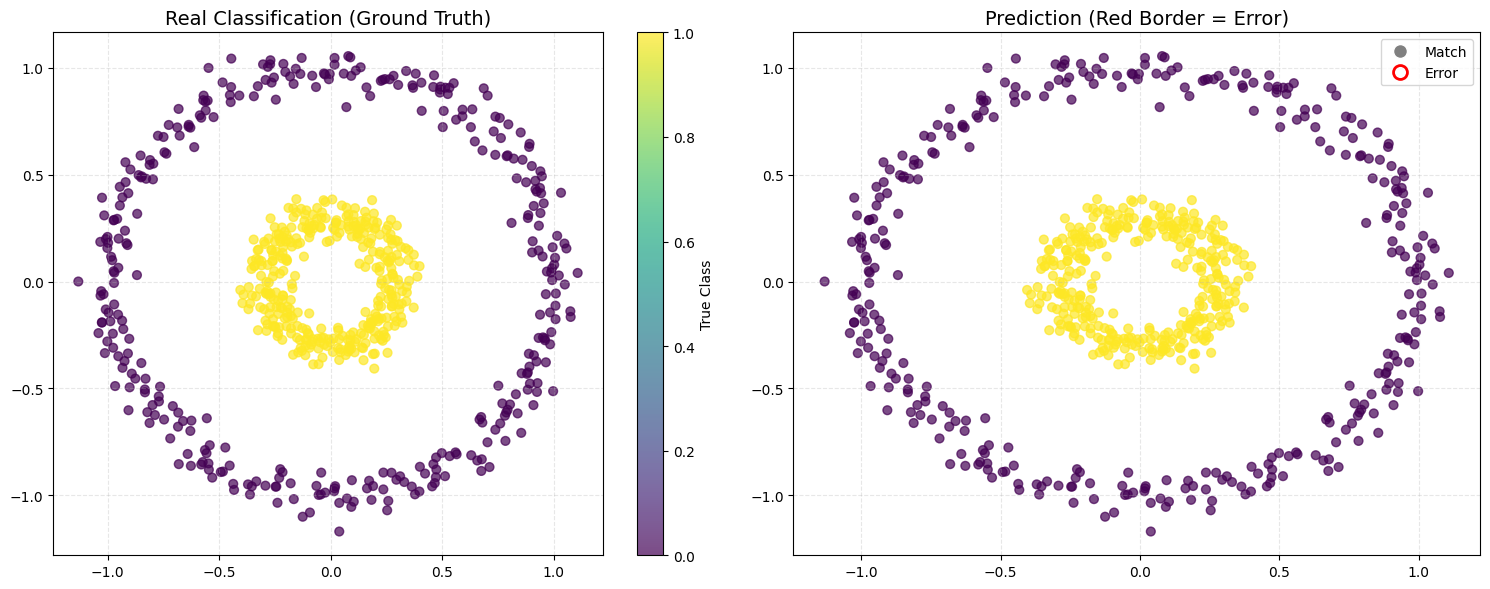

In [ ]:
from models.spectral import train_spectral
from utils.generate_data import generate_circles_data
from visualization.visualize_clustering_comparison import visualize_clustering_comparison

# 1. Retrieve the difficult data (Concentric Circles)
# 'factor=0.3' creates a significant gap between the inner and outer ring
X_circles, y_true = generate_circles_data(n_samples=700, noise=0.05, factor=0.3)

# 2. Train Spectral Clustering
# We use 'nearest_neighbors' to ensure the graph "follows" the geometry of the rings
spectral_labels = train_spectral(
    X_circles, 
    n_clusters=2, 
    affinity='nearest_neighbors', 
    n_neighbors=10
)

# 3. Visualization
print("--- Spectral Clustering (Based on Graphs and Eigenvectors) ---")
visualize_clustering_comparison(X_circles, y_true, spectral_labels)


# 7. Embedding Clustering 

Los métodos tradicionales (K-means, DBSCAN) fallan cuando los datos tienen **alta dimensionalidad** (imágenes, texto, audio) debido a la "Maldición de la Dimensionalidad": en espacios muy grandes, la distancia euclídea pierde sentido y todos los puntos parecen estar a la misma distancia.

**Deep Embedding Clustering (DEC)** soluciona esto utilizando Redes Neuronales Profundas para aprender una representación comprimida (feature learning) de los datos antes de agruparlos. Nostros trabajaremos con una versión simplificada.

### Arquitectura: El Autoencoder
La base de este método es el **Autoencoder**, una red neuronal entrenada para copiar su entrada en su salida ($x \approx x'$), pasando por un "cuello de botella" o espacio latente ($z$).

1.  **Encoder:** Comprime los datos originales $X$ a un espacio latente $Z$ de menor dimensión ($z = f(x)$).
2.  **Espacio Latente:** Aquí es donde reside la "esencia" de los datos. El ruido se elimina y la estructura se simplifica.
3.  **Decoder:** Intenta reconstruir los datos originales desde el espacio latente ($x' = g(z)$).
4.  **Clustering:** Una vez entrenada la red, desechamos el decoder y aplicamos K-means sobre el espacio latente $Z$.



### Objetivo Matemático
El objetivo real de DEC (Xie et al., 2016) es minimizar conjuntamente dos pérdidas:
$$L = L_{reconstrucción} + \lambda L_{clustering}$$
* **$L_{rec}$:** Qué tan bien se recupera la imagen original (MSE).
* **$L_{clust}$:** La divergencia KL entre la distribución de los puntos y una distribución objetivo (Student-t) que fuerza a los grupos a ser compactos.

---
### Referencias Bibliográficas 
> Xie, J., Girshick, R., & Farhadi, A. (2016). Unsupervised deep embedding for clustering analysis. *International conference on machine learning*, 478-487.

> Guo, X., Liu, X., Zhu, E., & Yin, J. (2017). Deep clustering with convolutional autoencoders. *International conference on neural information processing*, 373-382.

---
### Ejercicio 7: Clustering en el Espacio Latente (Caso Práctico: MNIST)

Hasta ahora hemos agrupado datos con pocas dimensiones. Sin embargo, en el mundo real nos enfrentamos a datos complejos como imágenes. En este ejercicio trabajaremos con el famoso dataset **MNIST**, compuesto por miles de imágenes de dígitos escritos a mano (del 0 al 9). 

Cada imagen tiene un tamaño de $28 \times 28$ píxeles, lo que significa que, si la aplanamos, cada dato tiene **784 dimensiones**. Aplicar un algoritmo de clustering directamente sobre 784 dimensiones suele ser ineficiente debido a la "Maldición de la Dimensionalidad" (las distancias euclídeas pierden representatividad).

Para solucionarlo, implementaremos una versión simplificada de **Deep Clustering**: utilizaremos una Red Neuronal Convolucional (Autoencoder) para que aprenda a extraer las características más importantes de los números y las comprima en un espacio más pequeño.



**Instrucciones del Ejercicio:**

1. **Entrenamiento del Autoencoder:** Entre una red neuronal enconder $f: R^{28 \times 28} \longrightarrow R^2$ y otra $h: R^2 \longrightarrow R^{28 \times 28} $ para minimizar MSE de $x$ y su reconstrucción $g(f(x))$ el modelo convolucional no supervisado. La red reducirá la dimensionalidad de las imágenes de forma no lineal. Utilice capas como `torch.nn.Conv2d` para reducir las dimensiones y `torch.nn.ConvTranspose2d`para su ampliación y reconstrucción.
2. **Extracción del Espacio Latente:** Una vez entrenada la red, pase todas las imágenes por el *Encoder*, $f$ para obtener sus vectores, $z = f(x)$  en el **espacio latente** (embedding de 2 dimensiones).
3. **Agrupación (Clustering):** Aplique el algoritmo de clustering anterior que desee sobre estos nuevos vectores bidimensionales.
4. **Comparación Visual:** Grafique el espacio latente coloreando los puntos según el clúster asignado y observe si los diferentes dígitos forman "islas" separadas de forma natural.

---

**Preguntas de Reflexión (Responda en una celda de texto):**

* **Análisis del Cuello de Botella:** En nuestro modelo actual, estamos comprimiendo 784 píxeles a únicamente **2 neuronas latentes**. Este es un "cuello de botella" extremo. Al observar el gráfico 2D resultante, notará que algunos números se solapan (por ejemplo, los 4 y los 9). ¿Qué tipo de información geométrica o visual cree que la red está viéndose obligada a sacrificar para lograr esta compresión tan agresiva?

* ¿Se te ocurre alguna otra alternativa para poder visualizar los datos en 2D y que el cuello de botella no sea tan agresivo?
* Puesto que disponemos de las etiquetas, mide **Adjusted Rand Index (ARI)** para ver cuánto se parece esta medición a la realidad: 
    Mide la similitud entre dos asignaciones de clústeres, considerando todos los pares de muestras y contando pares que son asignados al mismo o diferente clúster en ambas predicciones. Está "ajustado por azar" (corrige el hecho de que asignar al azar daría algunos aciertos).
    * Rango: **[-1, 1]**.
    * **1.0** indica coincidencia perfecta. **0.0** indica etiquetado aleatorio independiente.


Visualizing raw samples from the dataset...


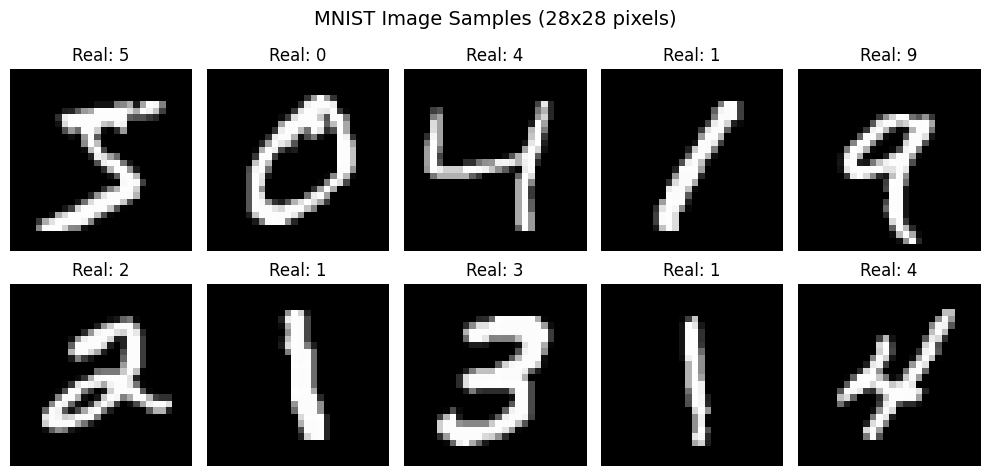

Training on: mps
Epoch 1/15, Average MSE Loss: 0.0836
Epoch 2/15, Average MSE Loss: 0.0586
Epoch 3/15, Average MSE Loss: 0.0557
Epoch 4/15, Average MSE Loss: 0.0545
Epoch 5/15, Average MSE Loss: 0.0537
Epoch 6/15, Average MSE Loss: 0.0530
Epoch 7/15, Average MSE Loss: 0.0525
Epoch 8/15, Average MSE Loss: 0.0521
Epoch 9/15, Average MSE Loss: 0.0517
Epoch 10/15, Average MSE Loss: 0.0513
Epoch 11/15, Average MSE Loss: 0.0509
Epoch 12/15, Average MSE Loss: 0.0506
Epoch 13/15, Average MSE Loss: 0.0503
Epoch 14/15, Average MSE Loss: 0.0500
Epoch 15/15, Average MSE Loss: 0.0497
Extracting 2D latent features...
Clustering with K-Means directly in 2D space...


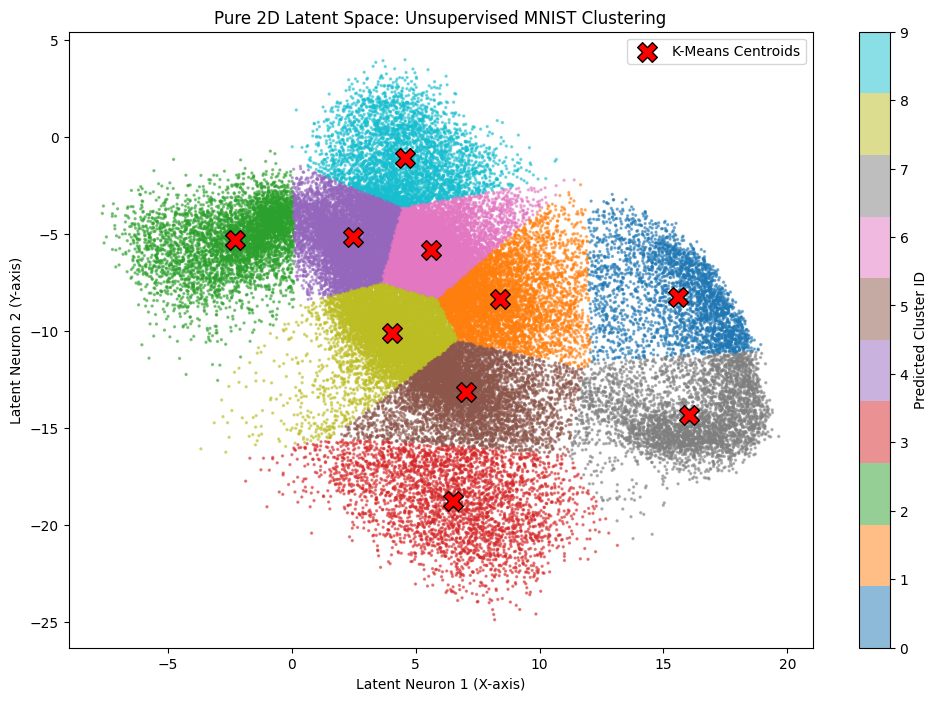

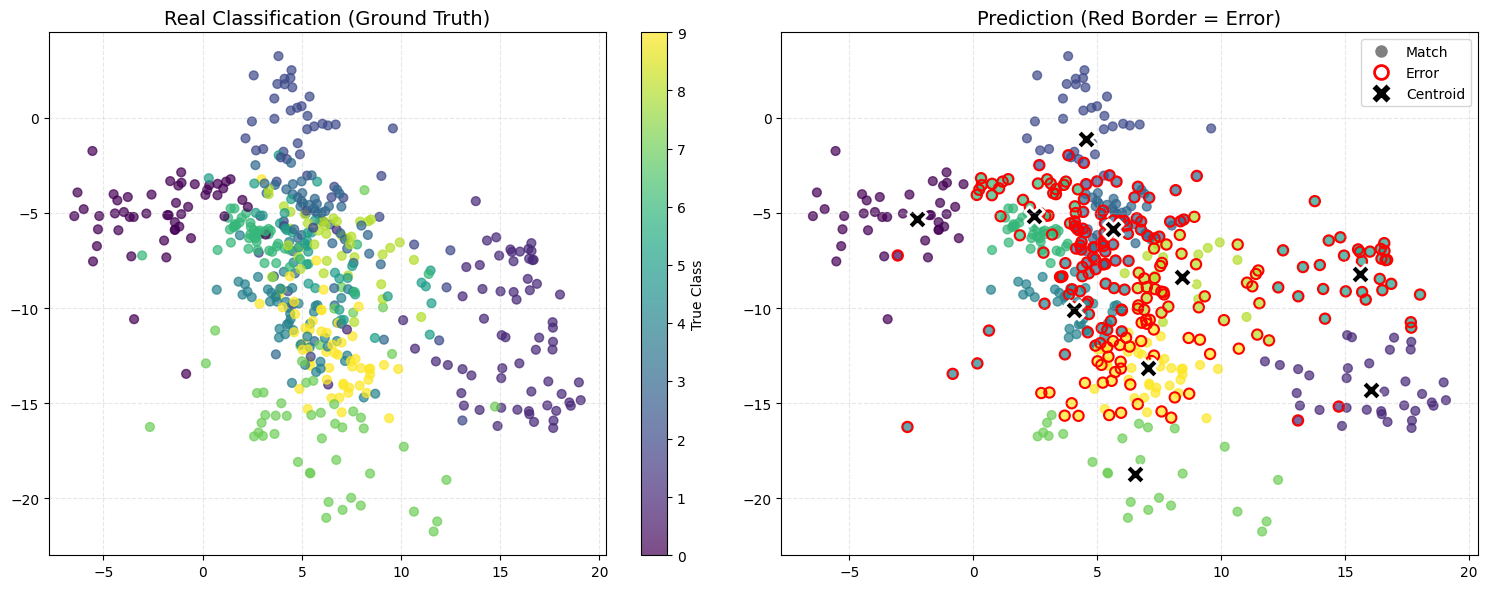

In [ ]:
import models.deep_clustering

### Ejercicio 8: Segmentación de Imágenes y Cuantización de Color con K-Means

Hasta ahora, hemos aplicado algoritmos de clustering a puntos abstractos en un plano o a datos estructurados. Sin embargo, el clustering tiene aplicaciones directas en el procesamiento de señales y la visión por computador. En este ejercicio, utilizaremos un método de clustering para realizar la **segmentación de una imagen** y reducir su paleta de colores (cuantización).

**¿Cómo convertimos una imagen en un dataset?**
Una imagen digital en color es esencialmente una cuadrícula de píxeles. Si una imagen tiene una resolución de $427 \times 640$ píxeles, contiene un total de $273,280$ píxeles. Cada uno de estos píxeles se puede representar como un punto en un espacio tridimensional definido por sus canales de color: **Rojo (R), Verde (G) y Azul (B)**. 

Por lo tanto, podemos "aplanar" la imagen para transformarla en una matriz de datos normal y corriente con forma `(273280, 3)`.


**El Proceso de Cuantización:**
1. Extraemos los valores RGB de todos los píxeles.
2. Pedimos a un algoritmo de clustering que encuentre $k$ clústeres en este espacio tridimensional de colores. Los centroides resultantes serán los $k$ "colores dominantes" de la imagen.
3. Reemplazamos el color original de cada píxel por el color del centroide al que fue asignado.
4. Reconstruimos la forma original de la imagen.

**Instrucciones del Ejercicio:**

A continuación, se le proporciona el código completo para cargar dos imágenes de muestra (`flower.jpg` y `china.jpg` integradas en `sklearn`) y aplicar la función `segmentar_imagen`. 

1. **Ejecute la celda de código** para procesar ambas imágenes. Note que el entrenamiento puede tardar unos segundos debido a la gran cantidad de píxeles.
2. **Analice los resultados visuales** comparando la imagen original con sus versiones comprimidas a $k=2$, $k=4$ y $k=16$ colores.

---

**Preguntas de Reflexión (Comente con sus compañeros o responda brevemente):**

* **Segmentación Binaria ($K=2$):** Observe el resultado cuando forzamos al algoritmo a usar solo 2 colores. ¿Qué elementos de la imagen original logra separar esta configuración? (Piense en términos de "Frente vs. Fondo" o "Luces vs. Sombras").
* **Compresión de Datos:** La imagen original puede tener decenas de miles de colores únicos. La versión de $K=16$ utiliza únicamente 16 colores, pero a simple vista conserva casi todos los detalles. ¿Cómo cree que se utiliza este principio geométrico en los formatos de compresión de imágenes que usamos a diario en la web (como el formato GIF, que limita los colores a 256)?

Processing image: flower.jpg
Training models...


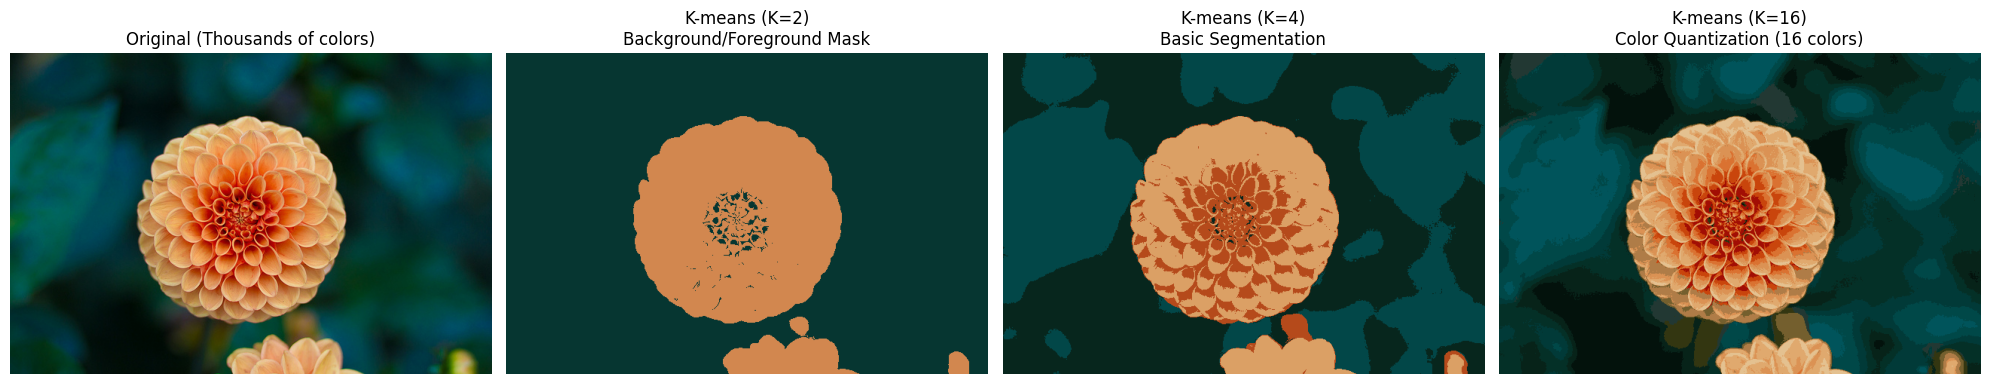

Processing image: china.jpg
Training models...


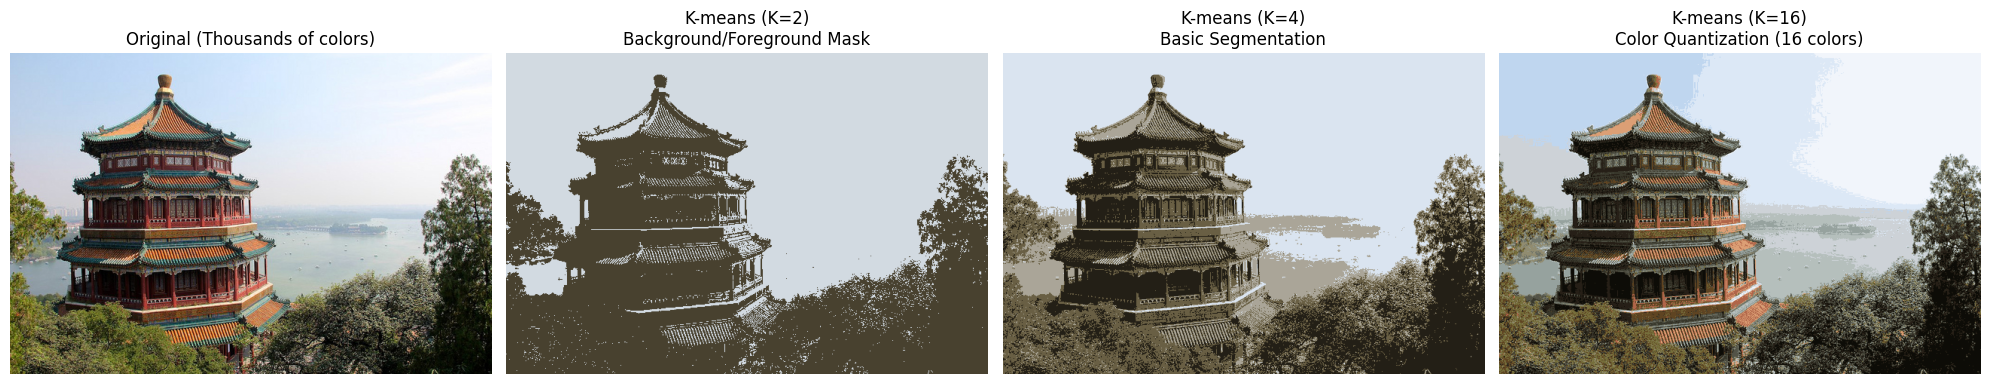

In [ ]:
import models.img_segmentation